# PROJET : Diversité & Inclusion – Analyse RH

---

## Contexte métier

La **Diversité & Inclusion (D&I)** est devenue un enjeu stratégique majeur pour les entreprises, sous l'effet conjugué de :
- **Obligations légales** : Index égalité professionnelle (loi Pénicaud 2018), obligation de résultat depuis 2022
- **Pression des investisseurs** : les critères ESG (Environnement, Social, Gouvernance) incluent les métriques D&I
- **Attraction des talents** : 76% des candidats évaluent la diversité d'une entreprise avant de postuler (Glassdoor 2020)
- **Performance prouvée** : les équipes diversifiées prennent de meilleures décisions dans 87% des cas (McKinsey)

## Obligations légales (France)

| Obligation | Détail |
|-----------|--------|
| **Index égalité F/H** | Score sur 100 pts (5 indicateurs), obligatoire > 50 salariés, publié chaque 1er mars |
| **Seuil de vigilance** | Score < 75/100 → plan d'action obligatoire |
| **Score critique** | Score < 85/100 → objectifs de progression publiés |
| **DOETH** | Déclaration obligatoire emploi travailleurs handicapés (SEEPH) |
| **Taux BOETH** | Obligation d'emploi 6% de travailleurs handicapés (loi 1987) |

## Objectifs du projet

1. **Auditer** les données D&I (problèmes d'encodage et de complétude fréquents)
2. **Mesurer** les métriques de représentation (genre, âge, nationalité)
3. **Analyser** l'équité salariale (écarts de rémunération contrôlés et bruts)
4. **Évaluer** les taux de promotion par groupe
5. **Calculer** l'Index Égalité F/H simplifié
6. **Formuler** un plan d'action D&I priorisé

## Stack technique

Python · Pandas · NumPy · Matplotlib · Seaborn · SciPy · Statsmodels

---

## Plan du notebook

| Section | Contenu |
|---------|----------|
| 1. Génération des données | 600 employés avec données démographiques + 9 défauts |
| 2. Audit Qualité D&I | Problèmes spécifiques aux données sensibles |
| 3. Nettoyage | Normalisation des encodages hétérogènes |
| 4. Représentation | Index de parité, pyramide des âges, nationalités |
| 5. Équité Salariale | Écart brut + écart contrôlé (régression), test statistique |
| 6. Pipeline Promotion | Taux de promotion par genre, grade, département |
| 7. Index Égalité F/H | Calcul simplifié de l'Index Pénicaud |
| 8. Plan d'Action D&I | Recommandations priorisées par impact |

---
## 1. Import & Génération des données

### ⚠️ Note sur les données sensibles

En France, la collecte de données sur l'**origine ethnique**, la **religion** ou l'**orientation sexuelle** est **interdite** (CNIL).  
Les données D&I légalement collectables sont : genre, âge, ancienneté, nationalité (pour l'international), situation de handicap (avec consentement).  
Ce projet simule des données **conformes au droit français**.

### Erreurs fréquentes dans les données D&I

Les données de genre, d'âge et de handicap souffrent souvent de :
- **Encodages multiples** : H/F, Homme/Femme, M/W, 1/2...
- **Taux de renseignement faible** : les employés hésitent à déclarer un handicap
- **Saisies manuelles** : fautes de frappe, majuscules inconsistantes
- **Migrations système** : différents référentiels entre entités d'un groupe

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (11, 5)
np.random.seed(42)

N = 600  # effectif simulé

In [2]:
# ── GÉNÉRATION DES DONNÉES PROPRES ────────────────────────────────────────────
# On simule une entreprise de taille intermédiaire avec un biais de genre
# volontairement introduit (les femmes sont sous-représentées aux grades supérieurs)

departements = ['Tech', 'Finance', 'Marketing', 'RH', 'Operations', 'Direction']
grades = ['G1', 'G2', 'G3', 'G4', 'G5']  # G1 = junior, G5 = senior/direction
nationalites = ['Française', 'Belge', 'Espagnole', 'Italienne', 'Britannique',
                'Allemande', 'Marocaine', 'Tunisienne', 'Sénégalaise',
                'Américaine', 'Indienne', 'Chinoise']
sources_recrutement = ['Cooptation', 'LinkedIn', 'Indeed', 'Cabinet', 'Alternance', 'Stage']

# Grade : pyramide des postes (G1 le plus représenté)
grade_col = np.random.choice(grades, N, p=[0.30, 0.30, 0.20, 0.12, 0.08])

# Genre : on introduit un biais → les femmes sont moins nombreuses aux grades G4/G5
# Probabilité d'être une femme selon le grade :
p_femme_par_grade = {'G1': 0.52, 'G2': 0.48, 'G3': 0.42, 'G4': 0.30, 'G5': 0.22}
genre_col = np.array([
    'F' if np.random.random() < p_femme_par_grade[g] else 'H'
    for g in grade_col
])

# Salaire : biais intentionnel (les femmes gagnent en moyenne 8% de moins à grade identique)
salaire_base_grade = {'G1': 32000, 'G2': 42000, 'G3': 54000, 'G4': 70000, 'G5': 95000}
salaire_col = np.array([
    int(salaire_base_grade[g] * (0.92 if genre == 'F' else 1.0) * np.random.normal(1.0, 0.10))
    for g, genre in zip(grade_col, genre_col)
])

# Âge : corrélé au grade
age_base = {'G1': 26, 'G2': 31, 'G3': 37, 'G4': 43, 'G5': 49}
age_col = np.array([
    int(np.clip(np.random.normal(age_base[g], 4), 22, 65))
    for g in grade_col
])

# Ancienneté : corrélée à l'âge
anciennete_col = np.clip(
    (age_col - 22) * np.random.uniform(0.3, 0.6, N), 0, 25
).astype(int)

# Handicap : taux de déclaration volontairement bas (réalisme : beaucoup ne déclarent pas)
# BOETH = Bénéficiaire de l'Obligation d'Emploi des Travailleurs Handicapés
boeth_col = np.random.choice(['Oui', 'Non', np.nan], N, p=[0.04, 0.60, 0.36])
# Note : 36% de NaN = non déclarés (champ facultatif avec consentement)

# Nationalité
nat_col = np.random.choice(nationalites, N,
    p=[0.65, 0.05, 0.05, 0.04, 0.03, 0.03, 0.04, 0.03, 0.02, 0.02, 0.02, 0.02])

# Département
dept_col = np.random.choice(departements, N,
    p=[0.25, 0.15, 0.15, 0.10, 0.25, 0.10])

# Dates
date_embauche_col = pd.to_datetime('2005-01-01') + pd.to_timedelta(
    np.random.randint(0, 19 * 365, N), unit='D'
)

# Dernière promotion : plus de femmes sans promotion récente
# Les femmes attendent en moyenne 1 an de plus entre deux promotions
annee_dernier_promo_col = np.array([
    int(np.clip(np.random.normal(2021 if g == 'F' else 2022, 2), 2015, 2024))
    for g in genre_col
])

# Source de recrutement
source_col = np.random.choice(sources_recrutement, N)

# Niveau d'éducation
niveaux_edu = ['Bac', 'Bac+2', 'Bac+3', 'Bac+5', 'Bac+8']
edu_col = np.random.choice(niveaux_edu, N, p=[0.05, 0.10, 0.25, 0.50, 0.10])

# Assemblage
df_raw = pd.DataFrame({
    'employee_id': range(3001, 3001 + N),
    'genre': genre_col,
    'age': age_col,
    'nationalite': nat_col,
    'boeth': boeth_col,  # Bénéficiaire Obligation Emploi Travailleur Handicapé
    'niveau_education': edu_col,
    'departement': dept_col,
    'grade': grade_col,
    'salaire': salaire_col,
    'anciennete': anciennete_col,
    'date_embauche': date_embauche_col,
    'annee_dernier_promo': annee_dernier_promo_col,
    'source_recrutement': source_col,
})

print(f"Dataset propre : {df_raw.shape}")
print(f"Répartition genre : {df_raw['genre'].value_counts().to_dict()}")
df_raw.head(3)

Dataset propre : (600, 13)
Répartition genre : {'H': 342, 'F': 258}


,employee_id,genre,age,nationalite,boeth,niveau_education,departement,grade,salaire,anciennete,date_embauche,annee_dernier_promo,source_recrutement
0,3001,F,29,Française,Non,Bac+3,Finance,G2,44689,3,2011-03-27,2019,Stage
1,3002,H,44,Allemande,nan,Bac+2,Marketing,G5,94375,11,2006-08-19,2020,LinkedIn
2,3003,F,37,Française,Non,Bac+5,RH,G3,46921,6,2015-08-11,2024,Indeed


In [3]:
# ── INJECTION DES DÉFAUTS QUALITÉ D&I ─────────────────────────────────────────
# Les défauts dans les données D&I ont des causes spécifiques :
# - Champs genre saisis en texte libre dans les anciens formulaires HR
# - Données de handicap rarement complètes (sensibilité + champ facultatif)
# - Nationalités mal normalisées (accent, abréviation, code pays)

df = df_raw.copy()

# DÉFAUT 1 : Genres mal encodés (multiples référentiels)
# → Fusion de deux systèmes : l'un utilise H/F, l'autre Homme/Femme
idx_genre = np.random.choice(df.index, size=35, replace=False)
variantes_genre = ['Homme', 'homme', 'HOMME', 'M', 'Male', 'male',
                   'Femme', 'femme', 'FEMME', 'W', 'Female', 'female', '0', '1']
df.loc[idx_genre, 'genre'] = np.random.choice(variantes_genre, size=35)
print(f"Défaut 1 – Genres mal encodés : 35 cas")

# DÉFAUT 2 : Âges impossibles
# → Inversion de chiffres lors d'une migration (18 → 81, 26 → 62)
idx_age = np.random.choice(df.index, size=5, replace=False)
df.loc[idx_age[:3], 'age'] = [15, 16, 14]   # trop jeunes
df.loc[idx_age[3:], 'age'] = [78, 82]        # trop vieux (retraite)
print(f"Défaut 2 – Âges impossibles : 5 cas")

# DÉFAUT 3 : Nationalités mal saisies
# → Variantes d'accent, abréviations, noms en anglais
idx_nat = np.random.choice(df.index, size=25, replace=False)
nat_variantes = ['française', 'FRANÇAISE', 'France', 'FR', 'Francaise',
                 'espagnol', 'ESPAGNOLE', 'Spain', 'marocain', 'Maroc',
                 'belge', 'Belgium', 'italy', 'allemand']
df.loc[idx_nat, 'nationalite'] = np.random.choice(nat_variantes, size=25)
print(f"Défaut 3 – Nationalités mal saisies : 25 cas")

# DÉFAUT 4 : Salaires négatifs (3) et zéros (2)
# → Erreurs de saisie ou valeurs par défaut non remplacées
idx_sal = np.random.choice(df.index, size=5, replace=False)
df.loc[idx_sal[:3], 'salaire'] = -df.loc[idx_sal[:3], 'salaire']
df.loc[idx_sal[3:], 'salaire'] = 0
print(f"Défaut 4 – Salaires invalides : 5 cas")

# DÉFAUT 5 : Salaires outliers extrêmes
idx_sal_out = np.random.choice(df.index, size=4, replace=False)
df.loc[idx_sal_out, 'salaire'] = [850000, 920000, 780000, 1100000]
print(f"Défaut 5 – Salaires outliers : 4 cas")

# DÉFAUT 6 : Ancienneté supérieure à l'âge - 16 (âge minimal de travail)
# → Erreur de calcul dans l'export (ancienneté en mois saisie en années)
idx_anc = np.random.choice(df.index, size=4, replace=False)
df.loc[idx_anc, 'anciennete'] = 60   # 60 ans d'ancienneté = impossible
print(f"Défaut 6 – Ancienneté incohérente : 4 cas")

# DÉFAUT 7 : Grades inexistants
# → Fusion d'une filiale avec un référentiel différent
idx_grade = np.random.choice(df.index, size=6, replace=False)
df.loc[idx_grade, 'grade'] = np.random.choice(['G6', 'G0', 'N/A', 'Expert'], size=6)
print(f"Défaut 7 – Grades invalides : 6 cas")

# DÉFAUT 8 : Dates d'embauche dans le futur
# → Contrats pré-signés saisis avec erreur de date
idx_date = np.random.choice(df.index, size=3, replace=False)
df.loc[idx_date, 'date_embauche'] = pd.to_datetime('2027-06-01')  # dans le futur
print(f"Défaut 8 – Dates futures : 3 cas")

# DÉFAUT 9 : Niveaux d'éducation non standardisés
# → Ancien système en anglais, nouveau en français
idx_edu = np.random.choice(df.index, size=20, replace=False)
edu_variantes = ['Master', 'master', 'BAC+5', 'Licence', 'licence', 'bac+3',
                 'Doctor', 'PhD', 'BTS', 'bachelor', 'Bac + 2']
df.loc[idx_edu, 'niveau_education'] = np.random.choice(edu_variantes, size=20)
print(f"Défaut 9 – Niveaux éducation non standardisés : 20 cas")

print(f"\n✅ Dataset avec défauts : {df.shape}")

Défaut 1 – Genres mal encodés : 35 cas
Défaut 2 – Âges impossibles : 5 cas
Défaut 3 – Nationalités mal saisies : 25 cas
Défaut 4 – Salaires invalides : 5 cas
Défaut 5 – Salaires outliers : 4 cas
Défaut 6 – Ancienneté incohérente : 4 cas
Défaut 7 – Grades invalides : 6 cas
Défaut 8 – Dates futures : 3 cas
Défaut 9 – Niveaux éducation non standardisés : 20 cas

✅ Dataset avec défauts : (600, 13)


---
## 2. Audit de Qualité – Données D&I

Les données D&I nécessitent un audit particulièrement attentif car :
- **Les erreurs d'encodage de genre** faussent l'Index Égalité Professionnelle
- **Les données BOETH manquantes** (handicap) sous-estiment le taux légal
- **Les erreurs de nationalité** impactent les statistiques d'internationalisation

In [4]:
# ── 2.1 VUE D'ENSEMBLE ────────────────────────────────────────────────────────
print("=" * 60)
print("AUDIT QUALITÉ – DONNÉES DIVERSITÉ & INCLUSION")
print("=" * 60)
print(f"Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}")
print()
df.info()
print()
df.describe(include='all').round(1)

AUDIT QUALITÉ – DONNÉES DIVERSITÉ & INCLUSION
Lignes : 600 | Colonnes : 13

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   employee_id          600 non-null    int64         
 1   genre                600 non-null    str           
 2   age                  600 non-null    int64         
 3   nationalite          600 non-null    str           
 4   boeth                600 non-null    str           
 5   niveau_education     600 non-null    str           
 6   departement          600 non-null    str           
 7   grade                600 non-null    str           
 8   salaire              600 non-null    int64         
 9   anciennete           600 non-null    int64         
 10  date_embauche        600 non-null    datetime64[us]
 11  annee_dernier_promo  600 non-null    int64         
 12  source_recrutement   600 no

,employee_id,genre,age,nationalite,boeth,niveau_education,departement,grade,salaire,anciennete,date_embauche,annee_dernier_promo,source_recrutement
count,600.0,600,600.0,600,600,600,600,600,600.0,600.0,600,600.0,600
unique,NaN,14,NaN,23,3,16,6,8,NaN,NaN,NaN,NaN,6
top,NaN,H,NaN,Française,Non,Bac+5,Tech,G1,NaN,NaN,NaN,NaN,Cooptation
freq,NaN,322,NaN,401,359,312,156,179,NaN,NaN,NaN,NaN,107
mean,3300.5,NaN,33.6,NaN,NaN,NaN,NaN,NaN,53953.3,5.1,2014-10-19 21:31:12,2021.1,NaN
min,3001.0,NaN,14.0,NaN,NaN,NaN,NaN,NaN,-56062.0,0.0,2005-01-05 00:00:00,2015.0,NaN
25%,3150.8,NaN,27.0,NaN,NaN,NaN,NaN,NaN,33543.2,2.0,2010-03-12 06:00:00,2020.0,NaN
50%,3300.5,NaN,32.0,NaN,NaN,NaN,NaN,NaN,43132.5,4.0,2014-12-05 12:00:00,2021.0,NaN
75%,3450.2,NaN,39.0,NaN,NaN,NaN,NaN,NaN,57795.8,7.0,2019-07-16 00:00:00,2022.2,NaN
max,3600.0,NaN,82.0,NaN,NaN,NaN,NaN,NaN,1100000.0,60.0,2027-06-01 00:00:00,2024.0,NaN


In [5]:
# ── 2.2 COMPLÉTUDE ────────────────────────────────────────────────────────────
missing = pd.DataFrame({
    'nb_manquants': df.isnull().sum(),
    'pct_manquants': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('pct_manquants', ascending=False)

print("\n📊 Valeurs manquantes :")
print(missing.to_string())

# Note spéciale sur le BOETH
boeth_na = df['boeth'].isnull().mean() * 100
boeth_oui = (df['boeth'] == 'Oui').mean() * 100
print(f"\n⚠️ BOETH (Handicap) :")
print(f"   Non déclarés (NaN)   : {boeth_na:.1f}% → champ facultatif, sous-estimation probable")
print(f"   Déclarés BOETH (Oui) : {boeth_oui:.1f}% (minimum légal = 6%)")
print(f"   {'🔴 Taux déclaré insuffisant' if boeth_oui < 6 else '✅ Taux légal potentiellement atteint'}")


📊 Valeurs manquantes :
                     nb_manquants  pct_manquants
employee_id                     0            0.0
genre                           0            0.0
age                             0            0.0
nationalite                     0            0.0
boeth                           0            0.0
niveau_education                0            0.0
departement                     0            0.0
grade                           0            0.0
salaire                         0            0.0
anciennete                      0            0.0
date_embauche                   0            0.0
annee_dernier_promo             0            0.0
source_recrutement              0            0.0

⚠️ BOETH (Handicap) :
   Non déclarés (NaN)   : 0.0% → champ facultatif, sous-estimation probable
   Déclarés BOETH (Oui) : 3.7% (minimum légal = 6%)
   🔴 Taux déclaré insuffisant


In [6]:
# ── 2.3 VALIDITÉ ET EXACTITUDE ───────────────────────────────────────────────
print("\n✅ Violations des règles métier :")
print("-" * 55)

grades_valides = ['G1', 'G2', 'G3', 'G4', 'G5']
genres_valides = ['H', 'F']
niveaux_valides = ['Bac', 'Bac+2', 'Bac+3', 'Bac+5', 'Bac+8']

# Date aujourd'hui
aujourd_hui = pd.Timestamp('2024-12-31')

checks = {
    'Genre non standardisé'          : (~df['genre'].isin(genres_valides)).sum(),
    'Âge < 18 ans'                   : (df['age'] < 18).sum(),
    'Âge > 70 ans'                   : (df['age'] > 70).sum(),
    'Salaire ≤ 0'                    : (df['salaire'] <= 0).sum(),
    'Salaire > 500 000 €'            : (df['salaire'] > 500_000).sum(),
    'Ancienneté > (âge - 16)'        : (df['anciennete'] > (df['age'] - 16)).sum(),
    'Grade invalide'                  : (~df['grade'].isin(grades_valides)).sum(),
    'Date embauche > aujourd\'hui'   : (pd.to_datetime(df['date_embauche']) > aujourd_hui).sum(),
    'Niveau éducation non std.'       : (~df['niveau_education'].isin(niveaux_valides)).sum(),
}

for regle, nb in checks.items():
    statut = '🔴' if nb > 0 else '🟢'
    print(f"   {statut} {regle:<40} : {nb} cas")

# Nationalités : valeurs uniques
print(f"\n📝 Nationalités uniques : {df['nationalite'].nunique()}")
print(df['nationalite'].value_counts().head(15).to_string())


✅ Violations des règles métier :
-------------------------------------------------------
   🔴 Genre non standardisé                    : 35 cas
   🔴 Âge < 18 ans                             : 3 cas
   🔴 Âge > 70 ans                             : 2 cas
   🔴 Salaire ≤ 0                              : 4 cas
   🔴 Salaire > 500 000 €                      : 4 cas
   🔴 Ancienneté > (âge - 16)                  : 7 cas
   🔴 Grade invalide                           : 6 cas
   🔴 Date embauche > aujourd'hui              : 3 cas
   🔴 Niveau éducation non std.                : 20 cas

📝 Nationalités uniques : 23
nationalite
Française      401
Belge           36
Allemande       20
Italienne       16
Espagnole       15
Britannique     15
Marocaine       15
Tunisienne      13
Américaine      13
Chinoise        12
Indienne        10
Sénégalaise      9
allemand         4
FR               3
italy            3


In [7]:
# ── 2.4 SCORE QUALITÉ D&I ────────────────────────────────────────────────────
total_cells = df.shape[0] * df.shape[1]
# Complétude : BOETH ignoré car naturellement incomplet
cols_oblig = [c for c in df.columns if c != 'boeth']
score_completude  = 1 - df[cols_oblig].isnull().sum().sum() / (df.shape[0] * len(cols_oblig))
score_unicite     = 1 - df.duplicated(subset='employee_id').sum() / len(df)
score_validite    = 1 - sum(checks.values()) / len(df)
# Cohérence : employés dont ancienneté ≤ âge - 16
score_coherence   = 1 - (df['anciennete'] > (df['age'] - 16)).sum() / len(df)
# Exactitude : % de lignes avec genre et grade valides
score_exactitude  = (df['genre'].isin(genres_valides) & df['grade'].isin(grades_valides)).mean()

score_global = np.mean([score_completude, score_unicite, score_validite,
                        score_coherence, score_exactitude]) * 100

print("\n" + "=" * 55)
print("RAPPORT QUALITÉ – DONNÉES D&I")
print("=" * 55)
dims = [
    ('Complétude',    score_completude),
    ('Unicité',       score_unicite),
    ('Validité',      score_validite),
    ('Cohérence',     score_coherence),
    ('Exactitude',    score_exactitude),
]
for dim, sc in dims:
    barre = '█' * int(sc * 20) + '░' * (20 - int(sc * 20))
    print(f"  {dim:<15} : {barre} {sc:.1%}")
print(f"\n  ⭐ SCORE GLOBAL : {score_global:.1f} / 100")
print("=" * 55)


RAPPORT QUALITÉ – DONNÉES D&I
  Complétude      : ████████████████████ 100.0%
  Unicité         : ████████████████████ 100.0%
  Validité        : █████████████████░░░ 86.0%
  Cohérence       : ███████████████████░ 98.8%
  Exactitude      : ██████████████████░░ 93.2%

  ⭐ SCORE GLOBAL : 95.6 / 100


---
## 3. Nettoyage des Données D&I

Le nettoyage des données D&I est **critique** : une normalisation incorrecte du genre fausserait l'Index Égalité qui est un indicateur légal.

In [8]:
df_clean = df.copy()
n_init = len(df_clean)

# ── ÉTAPE 1 : Standardiser les genres ────────────────────────────────────────
# Mapping exhaustif — tout ce qui n'est pas mappé devient NaN puis 'Inconnu'
mapping_genre = {
    'H': 'H', 'F': 'F',
    'Homme': 'H', 'homme': 'H', 'HOMME': 'H', 'M': 'H', 'Male': 'H', 'male': 'H', '1': 'H',
    'Femme': 'F', 'femme': 'F', 'FEMME': 'F', 'W': 'F', 'Female': 'F', 'female': 'F', '0': 'F'
}
df_clean['genre'] = df_clean['genre'].map(mapping_genre).fillna('Inconnu')
print(f"[1] Genres standardisés → valeurs : {df_clean['genre'].value_counts().to_dict()}")

# ── ÉTAPE 2 : Standardiser les nationalités ───────────────────────────────────
mapping_nat = {
    'française': 'Française', 'FRANÇAISE': 'Française', 'France': 'Française',
    'FR': 'Française', 'Francaise': 'Française',
    'espagnol': 'Espagnole', 'ESPAGNOLE': 'Espagnole', 'Spain': 'Espagnole',
    'marocain': 'Marocaine', 'Maroc': 'Marocaine',
    'belge': 'Belge', 'Belgium': 'Belge',
    'italy': 'Italienne', 'allemand': 'Allemande',
}
df_clean['nationalite'] = df_clean['nationalite'].replace(mapping_nat)
print(f"[2] Nationalités standardisées → {df_clean['nationalite'].nunique()} valeurs uniques")

# ── ÉTAPE 3 : Standardiser les niveaux d'éducation ───────────────────────────
mapping_edu = {
    'Master': 'Bac+5', 'master': 'Bac+5', 'BAC+5': 'Bac+5', 'bachelor': 'Bac+3',
    'Licence': 'Bac+3', 'licence': 'Bac+3', 'bac+3': 'Bac+3',
    'Doctor': 'Bac+8', 'PhD': 'Bac+8',
    'BTS': 'Bac+2', 'Bac + 2': 'Bac+2',
}
df_clean['niveau_education'] = df_clean['niveau_education'].replace(mapping_edu)
# Les valeurs non mappées → 'Non renseigné'
df_clean.loc[~df_clean['niveau_education'].isin(niveaux_valides), 'niveau_education'] = 'Non renseigné'
print(f"[3] Niveaux d'éducation standardisés")

# ── ÉTAPE 4 : Corriger les âges ───────────────────────────────────────────────
# Âges < 18 ou > 70 : on ne peut pas deviner la valeur correcte → on les met à NaN
# puis on impute par la médiane du grade
mask_age_inv = (df_clean['age'] < 18) | (df_clean['age'] > 70)
df_clean.loc[mask_age_inv, 'age'] = np.nan
df_clean['age'] = df_clean.groupby('grade')['age'].transform(
    lambda x: x.fillna(x.median())
).round(0).astype(int)
print(f"[4] Âges invalides imputés par médiane du grade : {mask_age_inv.sum()} cas")

# ── ÉTAPE 5 : Corriger les salaires ──────────────────────────────────────────
# Salaires ≤ 0 → valeur absolue ou médiane du grade
mask_sal_neg = df_clean['salaire'] <= 0
df_clean.loc[mask_sal_neg, 'salaire'] = np.nan
# Salaires > 500 000 → médiane du grade
mask_sal_out = df_clean['salaire'] > 500_000
df_clean.loc[mask_sal_out, 'salaire'] = np.nan
df_clean['salaire'] = df_clean.groupby('grade')['salaire'].transform(
    lambda x: x.fillna(x.median())
).astype(int)
print(f"[5] Salaires invalides corrigés ({mask_sal_neg.sum()} ≤0, {mask_sal_out.sum()} outliers)")

# ── ÉTAPE 6 : Ancienneté incohérente → ancienneté = âge - 22 max ─────────────
mask_anc = df_clean['anciennete'] > (df_clean['age'] - 16)
df_clean.loc[mask_anc, 'anciennete'] = (df_clean.loc[mask_anc, 'age'] - 22).clip(0)
print(f"[6] Ancienneté incohérente corrigée : {mask_anc.sum()} cas")

# ── ÉTAPE 7 : Grades invalides → 'Non classifié' ─────────────────────────────
mask_grade = ~df_clean['grade'].isin(grades_valides)
df_clean.loc[mask_grade, 'grade'] = 'Non classifié'
print(f"[7] Grades invalides marqués 'Non classifié' : {mask_grade.sum()} cas")

# ── ÉTAPE 8 : Dates futures ───────────────────────────────────────────────────
df_clean['date_embauche'] = pd.to_datetime(df_clean['date_embauche'])
mask_date = df_clean['date_embauche'] > pd.Timestamp('today')
df_clean.loc[mask_date, 'date_embauche'] = pd.NaT  # on les met à NaN (pas corrigeable sans info)
print(f"[8] Dates futures mises à NaT : {mask_date.sum()} cas")

# ── ÉTAPE 9 : Exclure les 'Inconnu' pour les analyses genre ──────────────────
# On garde un dataset principal propre et un dataset restreint aux genres connus
df_genre_connu = df_clean[df_clean['genre'].isin(['H', 'F'])].copy()

print(f"\n✅ Nettoyage terminé : {n_init} → {len(df_clean)} lignes")
print(f"   Lignes avec genre connu (H/F) : {len(df_genre_connu)}")

[1] Genres standardisés → valeurs : {'H': 340, 'F': 260}
[2] Nationalités standardisées → 12 valeurs uniques
[3] Niveaux d'éducation standardisés
[4] Âges invalides imputés par médiane du grade : 5 cas
[5] Salaires invalides corrigés (4 ≤0, 4 outliers)
[6] Ancienneté incohérente corrigée : 4 cas
[7] Grades invalides marqués 'Non classifié' : 6 cas
[8] Dates futures mises à NaT : 3 cas

✅ Nettoyage terminé : 600 → 600 lignes
   Lignes avec genre connu (H/F) : 600


---
## 4. Analyse de Représentation

La **représentation** mesure la présence de chaque groupe dans les différentes strates de l'organisation.  
Un **index de parité de 1.0** signifie une représentation proportionnelle à la population.

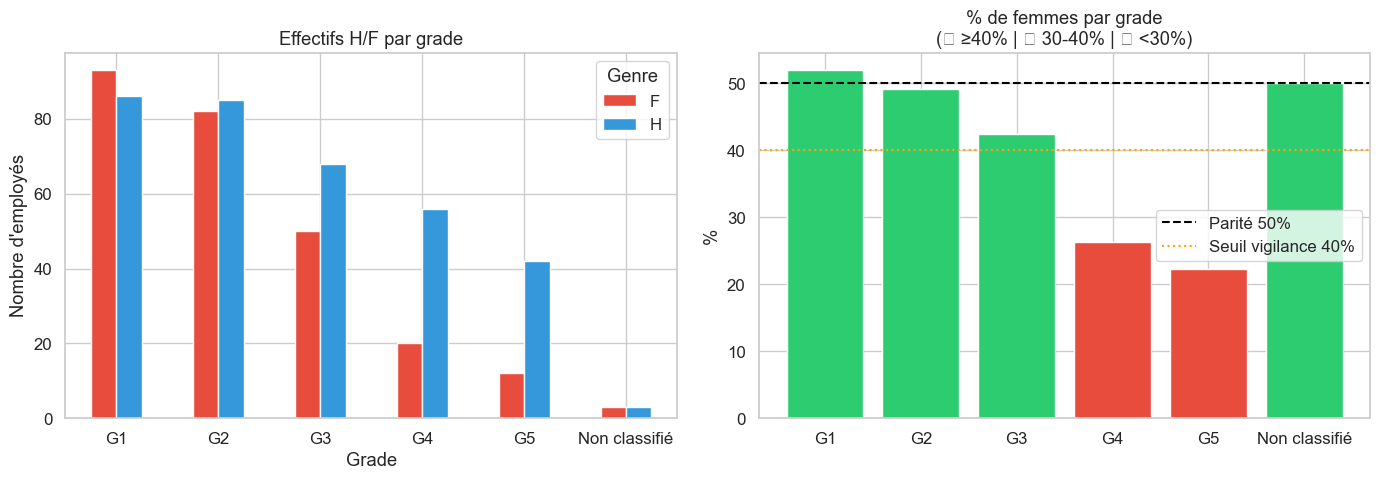


Pourcentage de femmes par grade :
grade
G1               52.0
G2               49.1
G3               42.4
G4               26.3
G5               22.2
Non classifié    50.0

Taux de féminisation global : 43.3%


In [9]:
# ── 4.1 RÉPARTITION GENRE PAR GRADE ──────────────────────────────────────────
# Le glass ceiling (plafond de verre) se traduit par une sous-représentation
# des femmes aux grades supérieurs.

genre_grade = df_genre_connu.groupby(['grade', 'genre']).size().unstack(fill_value=0)
genre_grade_pct = genre_grade.div(genre_grade.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar : effectifs
genre_grade.plot(kind='bar', ax=axes[0], color=['#E74C3C', '#3498DB'],
                 rot=0, edgecolor='white')
axes[0].set_title('Effectifs H/F par grade')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Nombre d\'employés')
axes[0].legend(title='Genre')

# % de femmes par grade (analyse du plafond de verre)
pct_femmes = genre_grade_pct.get('F', pd.Series(dtype=float))
colors_parity = ['#2ECC71' if v >= 40 else '#F39C12' if v >= 30 else '#E74C3C'
                 for v in pct_femmes]
axes[1].bar(pct_femmes.index, pct_femmes.values, color=colors_parity)
axes[1].axhline(50, color='black', linestyle='--', label='Parité 50%')
axes[1].axhline(40, color='orange', linestyle=':', label='Seuil vigilance 40%')
axes[1].set_title('% de femmes par grade\n(🟢 ≥40% | 🟡 30-40% | 🔴 <30%)')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nPourcentage de femmes par grade :")
print(pct_femmes.round(1).to_string())
print(f"\nTaux de féminisation global : {(df_genre_connu['genre'] == 'F').mean():.1%}")

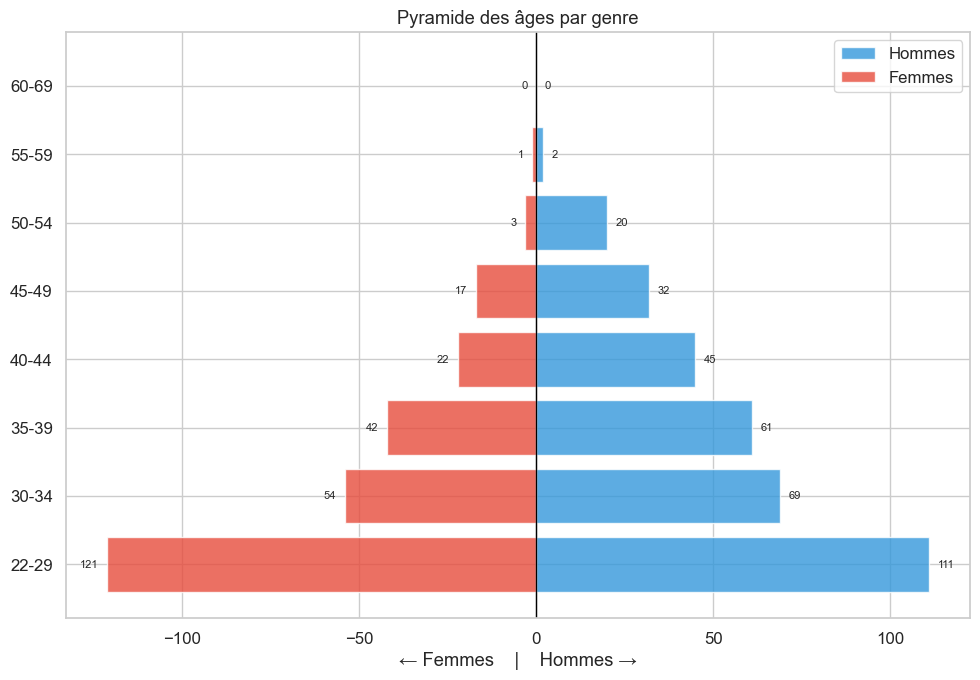


⚠️ Seniors (55+) : 3 employés (0.5% de l'effectif)
   Vigilance sur les transferts de compétences dans les 5-10 prochaines années.


In [10]:
# ── 4.2 PYRAMIDE DES ÂGES ─────────────────────────────────────────────────────
# La pyramide des âges est un outil RH fondamental pour anticiper les départs
# à la retraite, les besoins de recrutement et les transferts de compétences.

# Création des tranches d'âge
bins_age = [22, 30, 35, 40, 45, 50, 55, 60, 70]
labels_age = ['22-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-69']
df_genre_connu['tranche_age'] = pd.cut(
    df_genre_connu['age'], bins=bins_age, labels=labels_age, right=False
)

# Compter par tranche et genre
# observed=False pour inclure toutes les catégories même vides → évite le mismatch de shape
pyr = df_genre_connu.groupby(['tranche_age', 'genre'], observed=False).size().unstack(fill_value=0)
pyr = pyr.reindex(labels_age, fill_value=0)  # garantit les 8 tranches dans le bon ordre
hommes = pyr.get('H', pd.Series(0, index=pyr.index))
femmes = pyr.get('F', pd.Series(0, index=pyr.index))

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(labels_age))

# Hommes à droite, Femmes à gauche (convention pyramide des âges)
ax.barh(y, hommes.values, align='center', color='#3498DB', alpha=0.8, label='Hommes')
ax.barh(y, -femmes.values, align='center', color='#E74C3C', alpha=0.8, label='Femmes')

ax.set_yticks(y)
ax.set_yticklabels(labels_age)
ax.set_xlabel('← Femmes    |    Hommes →')
ax.set_title('Pyramide des âges par genre')
ax.axvline(0, color='black', linewidth=1)
ax.legend()

# Annoter les totaux par tranche
max_val = max(hommes.max(), femmes.max())
for i, (h, f) in enumerate(zip(hommes, femmes)):
    ax.text(h + max_val * 0.02, i, str(h), va='center', ha='left', fontsize=8)
    ax.text(-f - max_val * 0.02, i, str(f), va='center', ha='right', fontsize=8)

plt.tight_layout()
plt.show()

# Analyse des seniors (> 55 ans) → risque de départs à la retraite
seniors = (df_clean['age'] >= 55).sum()
print(f"\n⚠️ Seniors (55+) : {seniors} employés ({seniors/N:.1%} de l'effectif)")
print(f"   Vigilance sur les transferts de compétences dans les 5-10 prochaines années.")


🌍 Taux d'internationalisation : 32.3%


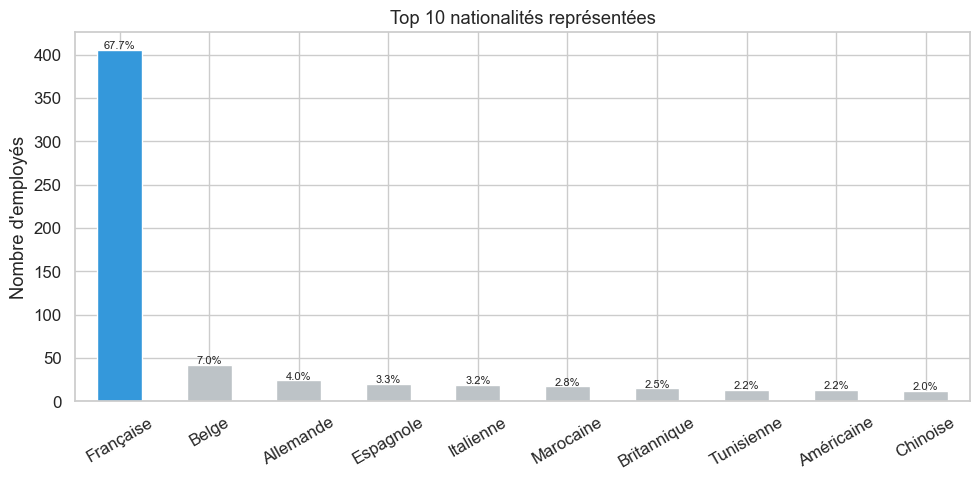

In [11]:
# ── 4.3 INTERNATIONALISATION ──────────────────────────────────────────────────
# L'internationalisation est un indicateur de diversité culturelle,
# valorisée dans les entreprises internationales.

# Taux d'internationalisation = % d'employés non-français
pct_non_fr = (df_clean['nationalite'] != 'Française').mean() * 100
print(f"\n🌍 Taux d'internationalisation : {pct_non_fr:.1f}%")

# Répartition des nationalités (top 10)
nat_counts = df_clean['nationalite'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors_nat = ['#3498DB' if n == 'Française' else '#BDC3C7' for n in nat_counts.index]
nat_counts.plot(kind='bar', ax=ax, color=colors_nat, rot=30, edgecolor='white')
ax.set_title('Top 10 nationalités représentées')
ax.set_ylabel('Nombre d\'employés')
ax.set_xlabel('')
for i, v in enumerate(nat_counts):
    ax.text(i, v + 1, f'{v/N:.1%}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 5. Analyse de l'Équité Salariale

### Deux types d'écarts salariaux

| Type | Description | Comment calculer |
|------|-------------|------------------|
| **Écart brut** | Différence de salaire moyen sans contrôle | `mean(salaire_H) - mean(salaire_F)` |
| **Écart contrôlé** | Différence à grade, département et ancienneté identiques | Régression linéaire avec variables de contrôle |

L'**écart brut** capte à la fois la discrimination salariale directe ET les effets de composition (les femmes sont moins souvent aux grades supérieurs).  
L'**écart contrôlé** isole uniquement la discrimination directe (à poste comparable).

ANALYSE ÉQUITÉ SALARIALE
  Salaire moyen Hommes    : 53,769 €
  Salaire moyen Femmes    : 42,007 €
  Écart brut              : 11,762 € (21.9%)
  (Benchmark France : ~16.8% selon Eurostat 2023)

  Test t de Welch (H0 : μH = μF) :
  t = 7.893, p-value = 0.0000
  → ✅ Écart significatif (α=5%)


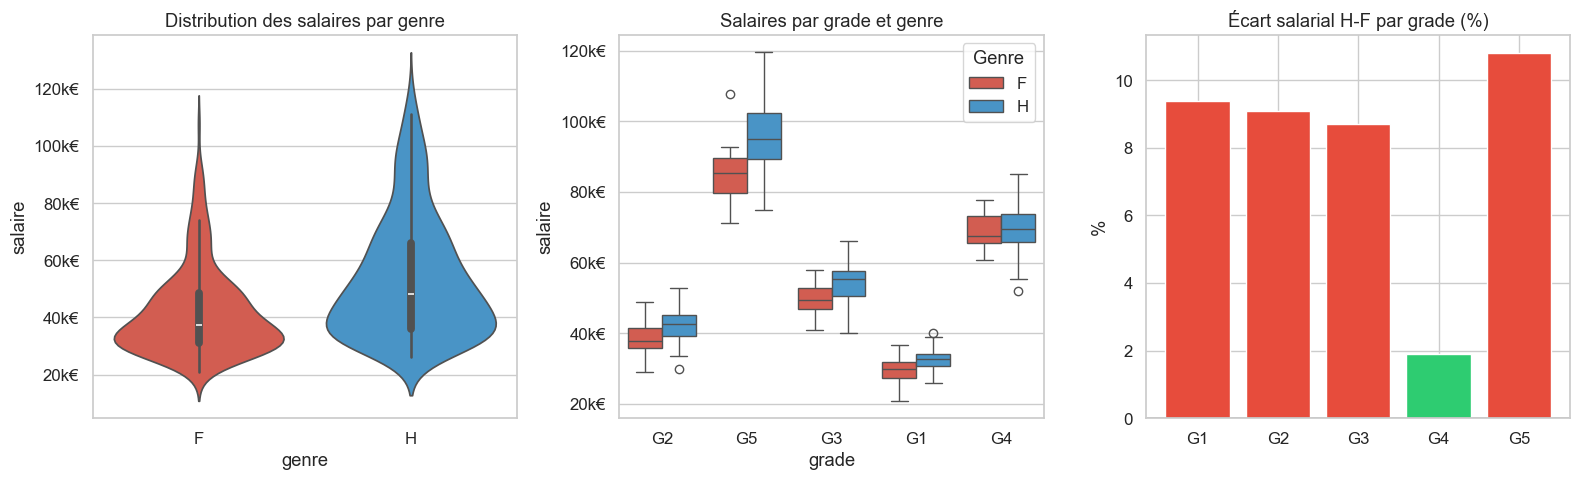


Écarts salariaux par grade :
genre        F        H  ecart_pct
grade                             
G1     29576.0  32637.0        9.0
G2     38656.0  42520.0        9.0
G3     49738.0  54452.0        9.0
G4     68653.0  69968.0        2.0
G5     85484.0  95881.0       11.0


In [12]:
# ── 5.1 ÉCART SALARIAL BRUT ───────────────────────────────────────────────────
sal_h = df_genre_connu[df_genre_connu['genre'] == 'H']['salaire']
sal_f = df_genre_connu[df_genre_connu['genre'] == 'F']['salaire']

ecart_brut = (sal_h.mean() - sal_f.mean())
ecart_pct = ecart_brut / sal_h.mean() * 100

print("=" * 55)
print("ANALYSE ÉQUITÉ SALARIALE")
print("=" * 55)
print(f"  Salaire moyen Hommes    : {sal_h.mean():,.0f} €")
print(f"  Salaire moyen Femmes    : {sal_f.mean():,.0f} €")
print(f"  Écart brut              : {ecart_brut:,.0f} € ({ecart_pct:.1f}%)")
print(f"  (Benchmark France : ~16.8% selon Eurostat 2023)")

# Test statistique : t-test bilatéral
# H0 : pas de différence significative de salaire entre H et F
t_stat, p_val = stats.ttest_ind(sal_h, sal_f, equal_var=False)  # Welch's t-test
print(f"\n  Test t de Welch (H0 : μH = μF) :")
print(f"  t = {t_stat:.3f}, p-value = {p_val:.4f}")
print(f"  → {'✅ Écart significatif' if p_val < 0.05 else '❌ Pas d\'écart significatif'} (α=5%)")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Violin plot
sns.violinplot(data=df_genre_connu, x='genre', y='salaire', ax=axes[0],
               palette={'H': '#3498DB', 'F': '#E74C3C'})
axes[0].set_title('Distribution des salaires par genre')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k€'))

# Box plot par grade et genre
sns.boxplot(data=df_genre_connu[df_genre_connu['grade'].isin(grades_valides)],
            x='grade', y='salaire', hue='genre',
            palette={'H': '#3498DB', 'F': '#E74C3C'}, ax=axes[1])
axes[1].set_title('Salaires par grade et genre')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k€'))
axes[1].legend(title='Genre')

# Écart moyen par grade
ecart_grade = df_genre_connu[df_genre_connu['grade'].isin(grades_valides)].groupby(
    ['grade', 'genre']
)['salaire'].mean().unstack()
ecart_grade['ecart_pct'] = ((ecart_grade['H'] - ecart_grade['F']) / ecart_grade['H'] * 100).round(1)
colors_ecart = ['#E74C3C' if v > 5 else '#F39C12' if v > 2 else '#2ECC71'
                for v in ecart_grade['ecart_pct']]
axes[2].bar(ecart_grade.index, ecart_grade['ecart_pct'], color=colors_ecart)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Écart salarial H-F par grade (%)')
axes[2].set_ylabel('%')

plt.tight_layout()
plt.show()
print("\nÉcarts salariaux par grade :")
print(ecart_grade.round(0).to_string())

In [13]:
# ── 5.2 ÉCART SALARIAL CONTRÔLÉ (Régression) ─────────────────────────────────
# On régresse le salaire sur le genre + variables de contrôle.
# Le coefficient de 'genre_H' donne l'écart à poste, ancienneté et département égaux.

# Préparation du dataset de régression
df_reg = df_genre_connu[df_genre_connu['grade'].isin(grades_valides)].copy()

# Encodage des variables catégorielles
df_reg_enc = pd.get_dummies(
    df_reg[['salaire', 'genre', 'grade', 'departement', 'anciennete', 'niveau_education']].dropna(),
    columns=['grade', 'departement', 'niveau_education'],
    drop_first=True
)
df_reg_enc['genre_H'] = (df_reg_enc['genre'] == 'H').astype(int)
df_reg_enc = df_reg_enc.drop('genre', axis=1)

# Régression OLS (Ordinary Least Squares) via scipy
# Variable dépendante : log(salaire) – log-transformation pour réduire l'asymétrie
df_reg_enc['log_salaire'] = np.log(df_reg_enc['salaire'])

y_reg = df_reg_enc['log_salaire']
X_reg = df_reg_enc.drop(['salaire', 'log_salaire'], axis=1)

# Régression linéaire multiple
from numpy.linalg import lstsq
X_with_const = np.column_stack([np.ones(len(X_reg)), X_reg.astype(float)])
coeffs, _, _, _ = lstsq(X_with_const, y_reg, rcond=None)

# Coefficient du genre (premier après la constante si genre_H en première position)
feature_names = ['constante'] + list(X_reg.columns)
coeff_dict = dict(zip(feature_names, coeffs))
coeff_genre = coeff_dict.get('genre_H', 0)

# Interpréter le coefficient log : exp(coeff) - 1 = % d'écart
ecart_controle_pct = (np.exp(coeff_genre) - 1) * 100

print("\n" + "=" * 55)
print("ÉCART SALARIAL CONTRÔLÉ")
print("=" * 55)
print(f"  Variables de contrôle : grade, département, ancienneté, éducation")
print(f"  Coefficient genre (log) : {coeff_genre:.4f}")
print(f"  Écart contrôlé estimé  : +{ecart_controle_pct:.1f}% en faveur des hommes")
print(f"\n  📊 Interprétation :")
print(f"     Écart BRUT    : {ecart_pct:.1f}% → capte aussi les effets de composition")
print(f"     Écart CONTRÔLÉ : {ecart_controle_pct:.1f}% → discrimination directe résiduelle")
print(f"     Différence    : {ecart_pct - ecart_controle_pct:.1f}pp expliqués par la sous-représentation aux grades supérieurs")


ÉCART SALARIAL CONTRÔLÉ
  Variables de contrôle : grade, département, ancienneté, éducation
  Coefficient genre (log) : 0.0892
  Écart contrôlé estimé  : +9.3% en faveur des hommes

  📊 Interprétation :
     Écart BRUT    : 21.9% → capte aussi les effets de composition
     Écart CONTRÔLÉ : 9.3% → discrimination directe résiduelle
     Différence    : 12.5pp expliqués par la sous-représentation aux grades supérieurs


---
## 6. Analyse du Pipeline de Promotion

Le **taux de promotion** est l'indicateur n°2 de l'Index Égalité Professionnelle.  
On analyse si les femmes sont promues à la même fréquence que les hommes.


📈 TAUX DE PROMOTION (2022-2024) :
           taux  nb_promus  effectif  taux_pct
genre                                         
F      0.280156         72       257      28.0
H      0.492582        166       337      49.3

  Écart taux de promotion H-F : +21.2 points de pourcentage

  Test χ² d'indépendance (genre × promotion) :
  χ² = 26.522, p-value = 0.0000, dof = 1
  → 🔴 Lien significatif (discrimination probable)


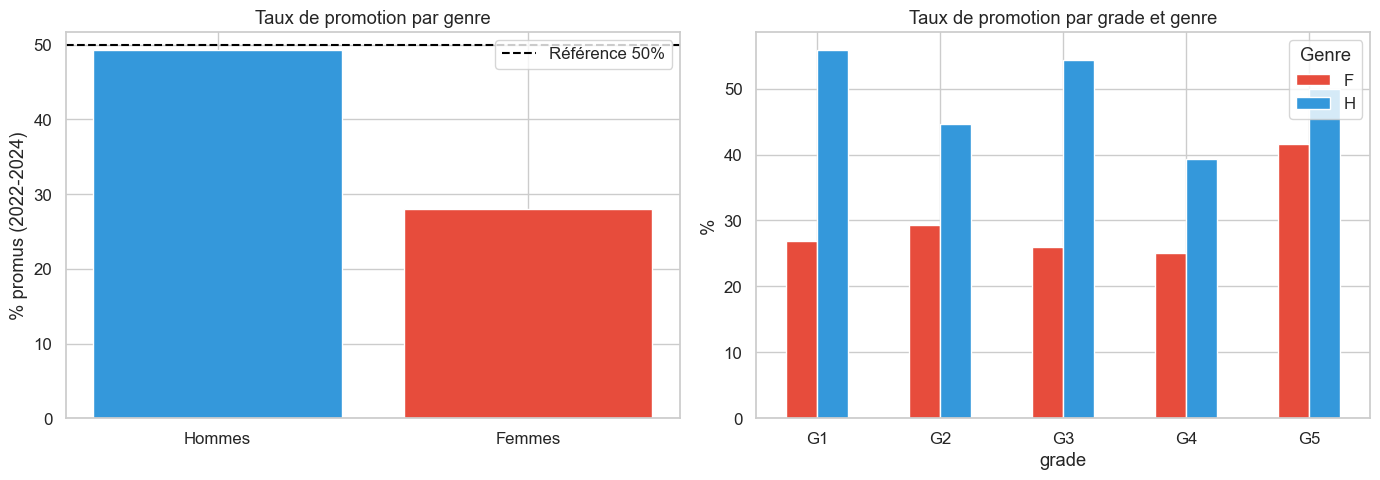

In [14]:
# ── 6.1 PROMOTIONS RÉCENTES (2022-2024) ───────────────────────────────────────
# On considère comme 'promu récemment' tout employé dont la dernière promotion
# date de 2022, 2023 ou 2024.

df_promo = df_genre_connu[df_genre_connu['grade'].isin(grades_valides)].copy()
df_promo['promo_recente'] = df_promo['annee_dernier_promo'] >= 2022

# Taux de promotion par genre
taux_promo_genre = df_promo.groupby('genre')['promo_recente'].agg(['mean', 'sum', 'count'])
taux_promo_genre.columns = ['taux', 'nb_promus', 'effectif']
taux_promo_genre['taux_pct'] = (taux_promo_genre['taux'] * 100).round(1)

print("\n📈 TAUX DE PROMOTION (2022-2024) :")
print(taux_promo_genre.to_string())

# Écart de promotion
taux_h = taux_promo_genre.loc['H', 'taux']
taux_f = taux_promo_genre.loc['F', 'taux']
ecart_promo = (taux_h - taux_f) * 100
print(f"\n  Écart taux de promotion H-F : {ecart_promo:+.1f} points de pourcentage")

# Test chi2 : est-ce que la promotion est indépendante du genre ?
contingence = pd.crosstab(df_promo['genre'], df_promo['promo_recente'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingence)
print(f"\n  Test χ² d'indépendance (genre × promotion) :")
print(f"  χ² = {chi2:.3f}, p-value = {p_chi2:.4f}, dof = {dof}")
print(f"  → {'🔴 Lien significatif (discrimination probable)' if p_chi2 < 0.05 else '🟢 Pas de lien significatif'}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux global par genre
axes[0].bar(['Hommes', 'Femmes'],
            [taux_h * 100, taux_f * 100],
            color=['#3498DB', '#E74C3C'])
axes[0].axhline(50, color='black', linestyle='--', label='Référence 50%')
axes[0].set_ylabel('% promus (2022-2024)')
axes[0].set_title('Taux de promotion par genre')
axes[0].legend()

# Taux de promotion par grade et genre
promo_grade_genre = df_promo.groupby(['grade', 'genre'])['promo_recente'].mean().unstack() * 100
promo_grade_genre.plot(kind='bar', ax=axes[1], color=['#E74C3C', '#3498DB'],
                       rot=0, edgecolor='white')
axes[1].set_title('Taux de promotion par grade et genre')
axes[1].set_ylabel('%')
axes[1].legend(title='Genre')

plt.tight_layout()
plt.show()

---
## 7. Index Égalité Professionnelle F/H (simplifié)

L'**Index Égalité Professionnelle** (ou « Index Pénicaud ») est un score sur 100 points calculé à partir de 5 indicateurs.

| Indicateur | Poids | Description |
|-----------|-------|-------------|
| 1. Écart de rémunération | 40 pts | Écart moyen par CSP et tranche d'âge |
| 2. Écart de taux d'augmentation | 20 pts | % d'augmentés parmi H vs F |
| 3. Écart de taux de promotion | 15 pts | % de promus parmi H vs F |
| 4. Augmentations post-congé maternité | 15 pts | 100 pts si 100% augmentées |
| 5. Représentation aux postes dirigeants | 10 pts | Parité parmi les 10 plus hautes rémunérations |

> ⚠️ Ce calcul est **simplifié** : l'index officiel requiert des tranches de rémunération et des groupes CSP spécifiques. On calcule ici une approximation pédagogique.

In [15]:
# ── CALCUL SIMPLIFIÉ DE L'INDEX ÉGALITÉ ──────────────────────────────────────

df_idx = df_genre_connu[df_genre_connu['grade'].isin(grades_valides)].copy()

# ── INDICATEUR 1 : Écart de rémunération (40 pts) ────────────────────────────
# L'index officiel compare par tranche d'âge × CSP
# Ici : on utilise les grades comme proxy CSP
ecart_by_grade = []
for g in grades_valides:
    sub = df_idx[df_idx['grade'] == g]
    if len(sub) > 5:  # au moins 5 obs par groupe
        moy_h = sub[sub['genre'] == 'H']['salaire'].mean()
        moy_f = sub[sub['genre'] == 'F']['salaire'].mean()
        if moy_h > 0 and not np.isnan(moy_f):
            ecart_by_grade.append(abs(moy_h - moy_f) / moy_h * 100)

ecart_moyen_idx = np.mean(ecart_by_grade) if ecart_by_grade else 0
# Barème officiel : 0% → 40pts, 5% → 34pts, 10% → 24pts, 15% → 14pts, ≥20% → 0pt
if ecart_moyen_idx < 3: pts_1 = 40
elif ecart_moyen_idx < 5: pts_1 = 34
elif ecart_moyen_idx < 7: pts_1 = 28
elif ecart_moyen_idx < 10: pts_1 = 20
elif ecart_moyen_idx < 15: pts_1 = 10
else: pts_1 = 0

# ── INDICATEUR 2 : Écart de taux d'augmentation (20 pts) ─────────────────────
# Simulation : on considère les augmentations = promotions récentes avec hausse de salaire
df_idx['augmente'] = df_idx['annee_dernier_promo'] >= 2023
taux_aug_h = df_idx[df_idx['genre'] == 'H']['augmente'].mean() * 100
taux_aug_f = df_idx[df_idx['genre'] == 'F']['augmente'].mean() * 100
ecart_aug = abs(taux_aug_h - taux_aug_f)
pts_2 = max(0, 20 - int(ecart_aug * 2))  # -2 pts par pp d'écart

# ── INDICATEUR 3 : Écart taux de promotion (15 pts) ──────────────────────────
ecart_promo_idx = abs(taux_h - taux_f) * 100
if ecart_promo_idx < 2: pts_3 = 15
elif ecart_promo_idx < 5: pts_3 = 10
elif ecart_promo_idx < 10: pts_3 = 5
else: pts_3 = 0

# ── INDICATEUR 4 : Congé maternité (15 pts) ──────────────────────────────────
# Données non disponibles dans notre simulation → on attribue 15 pts (favorable)
# En pratique, cet indicateur nécessite un suivi des congés maternité
pts_4 = 15  # score maximal assumé

# ── INDICATEUR 5 : Top 10 rémunérations (10 pts) ─────────────────────────────
top10 = df_idx.nlargest(10, 'salaire')
nb_femmes_top10 = (top10['genre'] == 'F').sum()
# L'indicateur est max si ≥ 4 femmes et ≥ 4 hommes parmi les 10 mieux payés
if nb_femmes_top10 >= 4: pts_5 = 10
elif nb_femmes_top10 == 3: pts_5 = 5
elif nb_femmes_top10 == 2: pts_5 = 2
else: pts_5 = 0

# ── SCORE TOTAL ───────────────────────────────────────────────────────────────
score_index = pts_1 + pts_2 + pts_3 + pts_4 + pts_5

print("=" * 60)
print("INDEX ÉGALITÉ PROFESSIONNELLE F/H (version simplifiée)")
print("=" * 60)
indicateurs = [
    ("1. Écart de rémunération",      pts_1, 40, f"Écart moyen : {ecart_moyen_idx:.1f}%"),
    ("2. Écart taux d'augmentation",  pts_2, 20, f"H:{taux_aug_h:.1f}% | F:{taux_aug_f:.1f}%"),
    ("3. Écart taux de promotion",    pts_3, 15, f"Écart : {ecart_promo_idx:.1f}pp"),
    ("4. Augmentation post-maternité",pts_4, 15, "Données non disponibles → score max"),
    ("5. Top 10 rémunérations",       pts_5, 10, f"{nb_femmes_top10} femmes parmi les 10 mieux payés"),
]
for indic, pts, max_pts, detail in indicateurs:
    print(f"  {indic:<40} : {pts:>3}/{max_pts} pts  ({detail})")

print(f"\n  ═══════════════════════════════════════")
print(f"  SCORE TOTAL : {score_index} / 100")

if score_index >= 85:
    verdict = "✅ BON – Publication recommandée"
elif score_index >= 75:
    verdict = "⚠️ VIGILANCE – Objectifs de progression à publier"
else:
    verdict = "🔴 CRITIQUE – Plan d'action obligatoire sous 3 ans"

print(f"  Verdict    : {verdict}")
print(f"  ═══════════════════════════════════════")

INDEX ÉGALITÉ PROFESSIONNELLE F/H (version simplifiée)
  1. Écart de rémunération                 :  20/40 pts  (Écart moyen : 8.0%)
  2. Écart taux d'augmentation             :   0/20 pts  (H:30.6% | F:17.9%)
  3. Écart taux de promotion               :   0/15 pts  (Écart : 21.2pp)
  4. Augmentation post-maternité           :  15/15 pts  (Données non disponibles → score max)
  5. Top 10 rémunérations                  :   0/10 pts  (1 femmes parmi les 10 mieux payés)

  ═══════════════════════════════════════
  SCORE TOTAL : 35 / 100
  Verdict    : 🔴 CRITIQUE – Plan d'action obligatoire sous 3 ans
  ═══════════════════════════════════════


---
## 8. Plan d'Action D&I & Dashboard

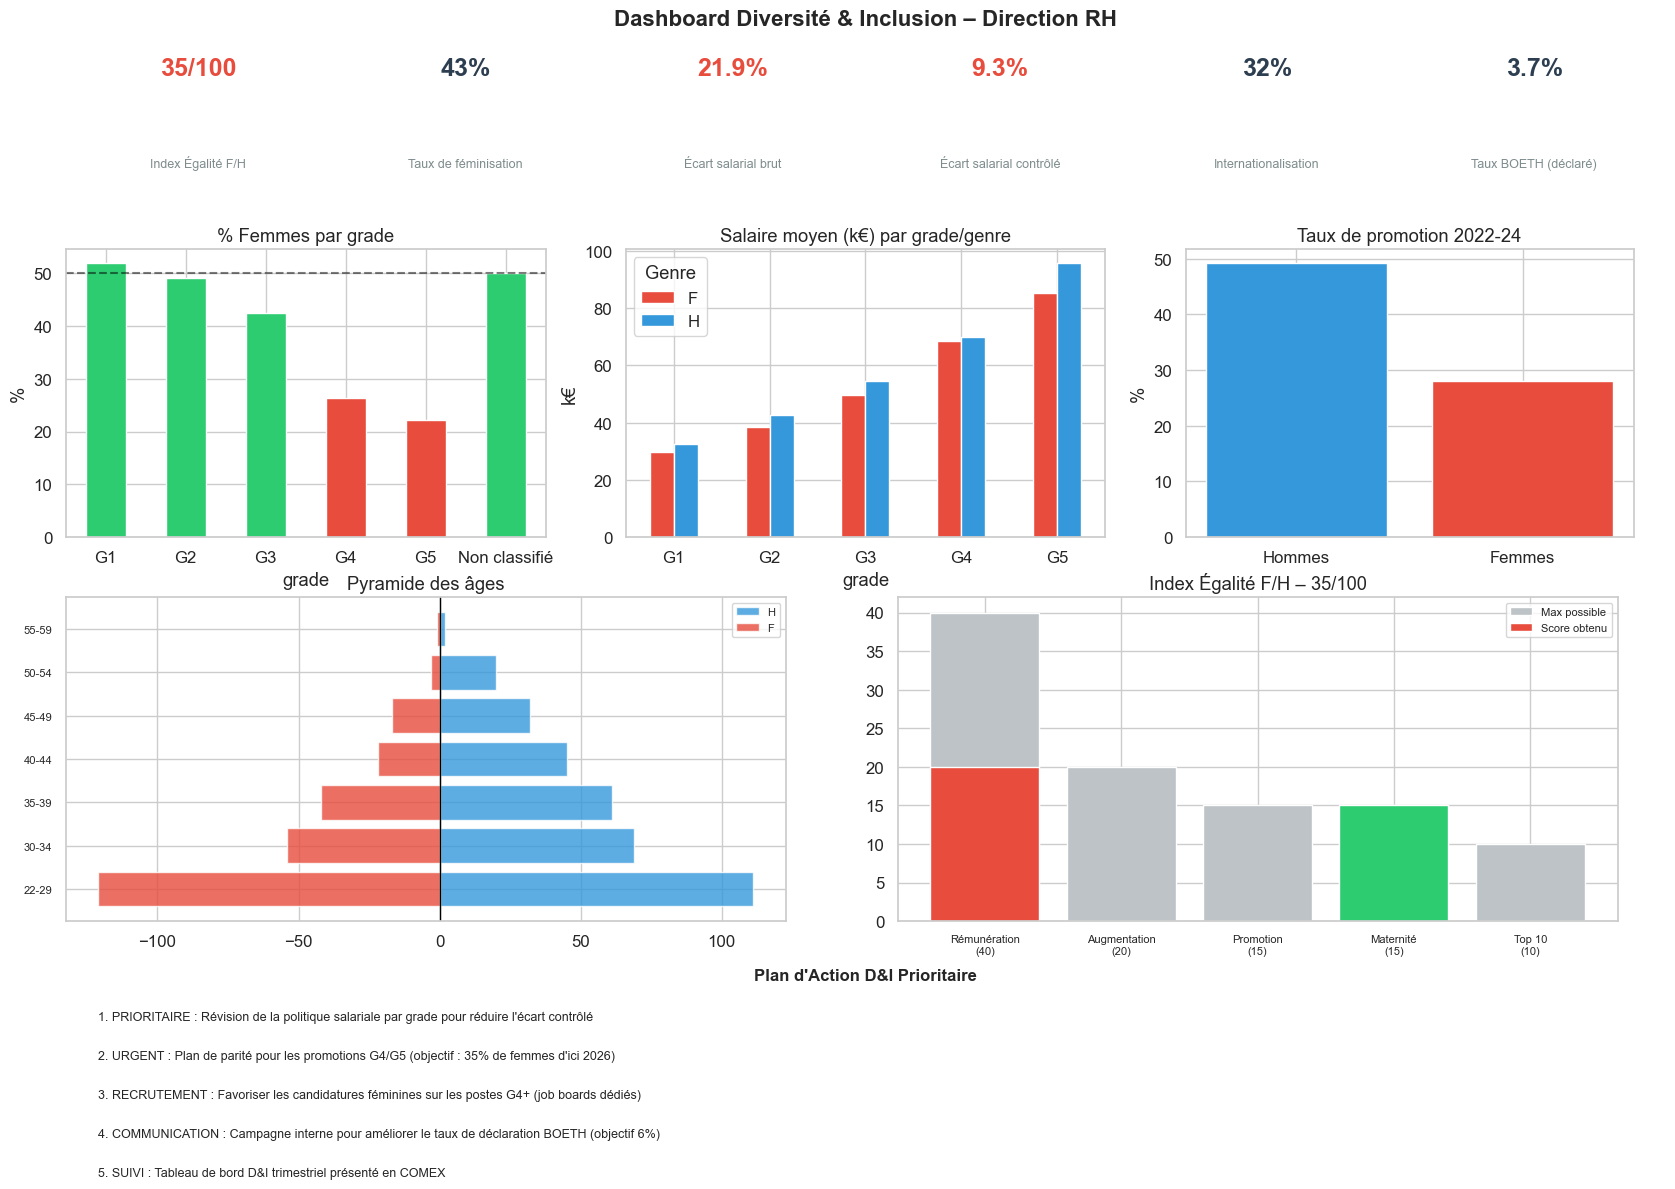

Dashboard sauvegardé → dashboard_diversite_inclusion.png


In [16]:
# ── DASHBOARD D&I ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Diversité & Inclusion – Direction RH', fontsize=16,
             fontweight='bold', y=0.98)

# KPIs
ax_kpi = fig.add_axes([0.0, 0.82, 1.0, 0.14])
ax_kpi.axis('off')
pct_femmes_global = (df_genre_connu['genre'] == 'F').mean() * 100
kpis = [
    (f"{score_index}/100", "Index Égalité F/H"),
    (f"{pct_femmes_global:.0f}%", "Taux de féminisation"),
    (f"{ecart_pct:.1f}%", "Écart salarial brut"),
    (f"{ecart_controle_pct:.1f}%", "Écart salarial contrôlé"),
    (f"{pct_non_fr:.0f}%", "Internationalisation"),
    (f"{boeth_oui:.1f}%", "Taux BOETH (déclaré)"),
]
for i, (val, label) in enumerate(kpis):
    x_pos = 0.083 + i * 0.167
    color = '#E74C3C' if (('Index' in label and score_index < 85) or
                          ('Écart' in label and float(val.replace('%','')) > 5)) else '#2C3E50'
    ax_kpi.text(x_pos, 0.75, val, ha='center', fontsize=18, fontweight='bold', color=color)
    ax_kpi.text(x_pos, 0.20, label, ha='center', fontsize=9, color='#7F8C8D')

# Graphe 1 : % femmes par grade
ax1 = fig.add_axes([0.0, 0.54, 0.30, 0.24])
pct_femmes_grade = genre_grade_pct.get('F', pd.Series(dtype=float))
pct_femmes_grade.plot(kind='bar', ax=ax1, rot=0,
    color=['#2ECC71' if v >= 40 else '#F39C12' if v >= 30 else '#E74C3C'
           for v in pct_femmes_grade])
ax1.axhline(50, color='black', linestyle='--', alpha=0.5)
ax1.set_title('% Femmes par grade')
ax1.set_ylabel('%')

# Graphe 2 : Salaires par grade et genre
ax2 = fig.add_axes([0.35, 0.54, 0.30, 0.24])
sal_by_grade_genre = df_idx.groupby(['grade', 'genre'])['salaire'].mean().unstack() / 1000
sal_by_grade_genre.plot(kind='bar', ax=ax2, rot=0,
                        color=['#E74C3C', '#3498DB'], edgecolor='white')
ax2.set_title('Salaire moyen (k€) par grade/genre')
ax2.set_ylabel('k€')
ax2.legend(title='Genre')

# Graphe 3 : Taux de promotion
ax3 = fig.add_axes([0.70, 0.54, 0.28, 0.24])
promo_by_genre = df_promo.groupby('genre')['promo_recente'].mean() * 100
ax3.bar(['Hommes', 'Femmes'],
        [promo_by_genre.get('H', 0), promo_by_genre.get('F', 0)],
        color=['#3498DB', '#E74C3C'])
ax3.set_title('Taux de promotion 2022-24')
ax3.set_ylabel('%')

# Graphe 4 : Pyramide des âges (simplifiée)
ax4 = fig.add_axes([0.0, 0.22, 0.45, 0.27])
pyr_simple = df_genre_connu.groupby(['tranche_age', 'genre'], observed=True).size().unstack(fill_value=0)
h_vals = pyr_simple.get('H', pd.Series(0, index=pyr_simple.index))
f_vals = pyr_simple.get('F', pd.Series(0, index=pyr_simple.index))
y_pos = np.arange(len(pyr_simple.index))
ax4.barh(y_pos, h_vals.values, color='#3498DB', alpha=0.8, label='H')
ax4.barh(y_pos, -f_vals.values, color='#E74C3C', alpha=0.8, label='F')
ax4.set_yticks(y_pos)
ax4.set_yticklabels(pyr_simple.index, fontsize=8)
ax4.axvline(0, color='black', linewidth=1)
ax4.set_title('Pyramide des âges')
ax4.legend(fontsize=8)

# Graphe 5 : Index avec barème
ax5 = fig.add_axes([0.52, 0.22, 0.45, 0.27])
noms_indic = ['Rémunération\n(40)', 'Augmentation\n(20)', 'Promotion\n(15)',
              'Maternité\n(15)', 'Top 10\n(10)']
pts_obtenus = [pts_1, pts_2, pts_3, pts_4, pts_5]
pts_max = [40, 20, 15, 15, 10]
x_pos_bar = np.arange(len(noms_indic))
ax5.bar(x_pos_bar, pts_max, color='#BDC3C7', label='Max possible')
ax5.bar(x_pos_bar, pts_obtenus,
        color=['#2ECC71' if p == m else '#E74C3C' for p, m in zip(pts_obtenus, pts_max)],
        label='Score obtenu')
ax5.set_xticks(x_pos_bar)
ax5.set_xticklabels(noms_indic, fontsize=8)
ax5.set_title(f'Index Égalité F/H – {score_index}/100')
ax5.legend(fontsize=8)

# Recommandations
ax6 = fig.add_axes([0.0, 0.01, 1.0, 0.18])
ax6.axis('off')
recommandations = [
    "1. PRIORITAIRE : Révision de la politique salariale par grade pour réduire l'écart contrôlé",
    "2. URGENT : Plan de parité pour les promotions G4/G5 (objectif : 35% de femmes d'ici 2026)",
    "3. RECRUTEMENT : Favoriser les candidatures féminines sur les postes G4+ (job boards dédiés)",
    "4. COMMUNICATION : Campagne interne pour améliorer le taux de déclaration BOETH (objectif 6%)",
    "5. SUIVI : Tableau de bord D&I trimestriel présenté en COMEX",
]
ax6.text(0.5, 0.95, 'Plan d\'Action D&I Prioritaire', ha='center', fontsize=12,
         fontweight='bold', va='top')
for i, reco in enumerate(recommandations):
    ax6.text(0.02, 0.75 - i * 0.18, reco, ha='left', fontsize=9, va='top')

plt.savefig('dashboard_diversite_inclusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard sauvegardé → dashboard_diversite_inclusion.png")